PCA (Principle Component Analysis)

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# Creating random dataset
n_samples = 200

t = np.random.normal(loc=0.0, scale=5.0, size=n_samples)

feature1 = t + np.random.normal(loc=0.0, scale=0.5, size=n_samples)
feature2 = 2 * t + np.random.normal(loc=0.0, scale=0.5, size=n_samples)

feature3 = np.random.normal(loc=0.0, scale=1.0, size=n_samples)

df = pd.DataFrame({
    'Feature_1': feature1,
    'Feature_2': feature2,
    'Feature_3': feature3
})

df['target'] = np.random.randint(0, 2, size=n_samples)

df.sample(10)

,Feature_1,Feature_2,Feature_3,target
118,-0.042277,1.765582,-0.317573,1
38,-1.052683,-2.202362,0.842450,0
24,7.047037,14.061319,0.404257,0
126,0.388627,0.758039,-0.594366,0
105,-6.330111,-14.653358,0.161563,1
158,0.262134,-0.690174,-1.700205,1
39,4.650074,10.782419,-0.362716,0
54,4.060009,8.323312,1.264578,0
130,-3.880476,-7.595687,0.342612,0
141,2.477268,5.494322,-1.013738,1


In [ ]:
# Visualizing through plotly in a 3D space
import plotly.express as px
fig = px.scatter_3d(df, x='Feature_1', y='Feature_2', z='Feature_3', color='target')
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df.iloc[:,0:2] = sc.fit_transform(df.iloc[:,0:2])

In [ ]:
cov_mat = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print("Covariance Matrix\n")
cov_mat

Covariance Matrix



array([[1.00502513, 1.00009669, 0.00277901],
       [1.00009669, 1.00502513, 0.00290288],
       [0.00277901, 0.00290288, 0.80181054]])

In [ ]:
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

In [ ]:
eigen_values

array([2.00513523, 0.00492843, 0.80179713])

In [ ]:
eigen_vectors

array([[ 7.07102736e-01,  7.07106621e-01, -2.43862769e-03],
       [ 7.07102943e-01, -7.07106933e-01, -2.28317346e-03],
       [ 3.33881761e-03,  1.09922613e-04,  9.99994420e-01]])

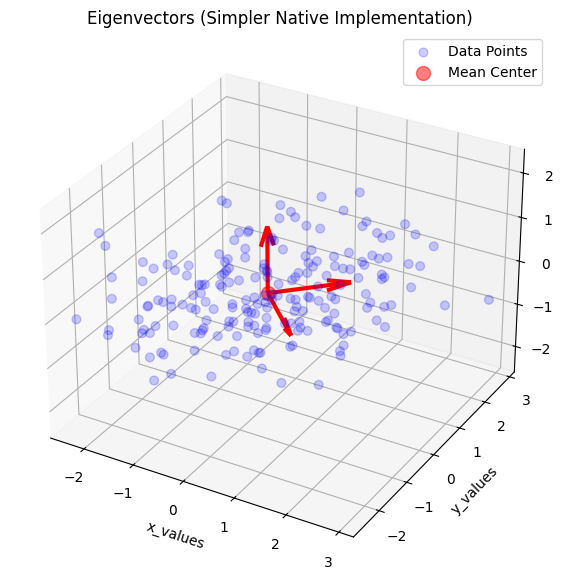

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Feature_1'], df['Feature_2'], df['Feature_3'],
           color='blue', alpha=0.2, s=40, label='Data Points')

mean_x = df['Feature_1'].mean()
mean_y = df['Feature_2'].mean()
mean_z = df['Feature_3'].mean()

ax.scatter([mean_x], [mean_y], [mean_z],
           color='red', alpha=0.5, s=100, label='Mean Center')

for v in eigen_vectors.T:
    ax.quiver(mean_x, mean_y, mean_z,
              v[0], v[1], v[2],
              color='r', linewidth=3,
              length=1.5, normalize=True)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('Eigenvectors (Simpler Native Implementation)')
plt.legend()
plt.show()

In [ ]:
pc = eigen_vectors[0:2]
pc

array([[ 0.70710274,  0.70710662, -0.00243863],
       [ 0.70710294, -0.70710693, -0.00228317]])

In [ ]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 200,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target']
new_df

,PC1,PC2,target
0,0.102540,0.038864,1
1,-1.132013,0.140399,0
2,-0.072632,-0.002768,0
3,-0.590450,-0.004000,1
4,-0.720912,0.128629,1
...,...,...,...
195,1.808219,-0.013054,1
196,-0.199496,0.058813,1
197,-2.033542,-0.062527,1
198,-0.829176,-0.122180,1


In [ ]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()
